# Timeline of novel epidemic-inducing symptoms

- **Summary**: This document graphs the arrival of epidemics caused by novel symptoms. 
- **Data Required:** `epidemics_marani_240816.xlsx`

- **Note:** Malaria and mpox (monkeypox) are not in the dataset because they have only caused outbreaks. 

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 10, 2024

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# Set filepaths
rawdata_dir = Path("../../data/raw").resolve()
cleandata_dir = Path("../../data/clean").resolve()
figdir = Path("../../output/exceedance_figures").resolve()

In [3]:
# Load seaborn style for publication-quality figures
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11
})

## 0. Prepare epidemic data

In [4]:
## Read epidemic data
df = pd.read_excel(rawdata_dir / "epidemics_marani_240816.xlsx")

## Sort epidemics by start year
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)


In [5]:
## Display dataset head
# df.head()


## 1. Prepare dataframe for novel symptoms

In [6]:
## Keep only the first occurrence of 'disease' column
df_arrival = df.drop_duplicates(subset='disease', keep='first').reset_index(drop=True)

## Create new disease column
df_arrival['new_disease'] = df_arrival['disease']


In [7]:
## Display dataset
# df_arrival


In [8]:
## Clean epidemics caused by multiple symptoms
df_arrival['new_disease'] = df_arrival['new_disease'].replace("typhus, dysentery", "dysentery")
df_arrival['new_disease'] = df_arrival['new_disease'].replace("typhus, relapsing fever, dysentery", "relapsing fever")
df_arrival['new_disease'] = df_arrival['new_disease'].replace("typhus, typhoid, dysentery", "typhoid")

## Drop later duplicates of "dysentery," "relapsing fever," "typhoid"
df_arrival_new = df_arrival.drop_duplicates(subset='new_disease', keep='first').reset_index(drop=True)


In [9]:
## Display dataset
# df_arrival_new


## 2. Graph timeline for novel epidemic-inducing symptoms

In [10]:
## Prepare symptom arrival data for graph
viral_df = df_arrival_new[df_arrival_new['is_vira_only'] == 1]
nonviral_df = df_arrival_new[df_arrival_new['is_vira_only'] == 0]

## Since some symptoms are caused by both viral and non-viral infections,
## we can also consider all symptoms with viral infections as "viral"
# viral_df = df_arrival_new[df_arrival_new['contains_vira'] == 1]
# nonviral_df = df_arrival_new[df_arrival_new['contains_vira'] == 0]


In [11]:
## Group unique viral/non-viral diseases by epidemic start year,
## in case more than 1 unique novel disease arrives in a year
viral_per_year = viral_df.groupby('year_start')['new_disease'].unique()
nonviral_per_year = nonviral_df.groupby('year_start')['new_disease'].unique()


In [12]:
## Set paramters of graph titles and markers
title_size = 12
markersize = 15

## Set parameters of symptom labels
fontsize = 9
initial_offset = 0.14
offset = 0.18


Text(1500, 1.0, 'Unknown')

Text(1507, 0.9743589743589743, 'Smallpox')

Text(1510, 0.9487179487179487, 'Influenza')

Text(1519, 0.9230769230769231, 'Plague')

Text(1528, 0.8974358974358975, 'Typhus')

...

(1495.0, 2024.0)

(-0.05, 1.05)

Text(0, 0.5, 'Disease')

[]

Text(0.5, 1.0, 'First recorded outbreak')

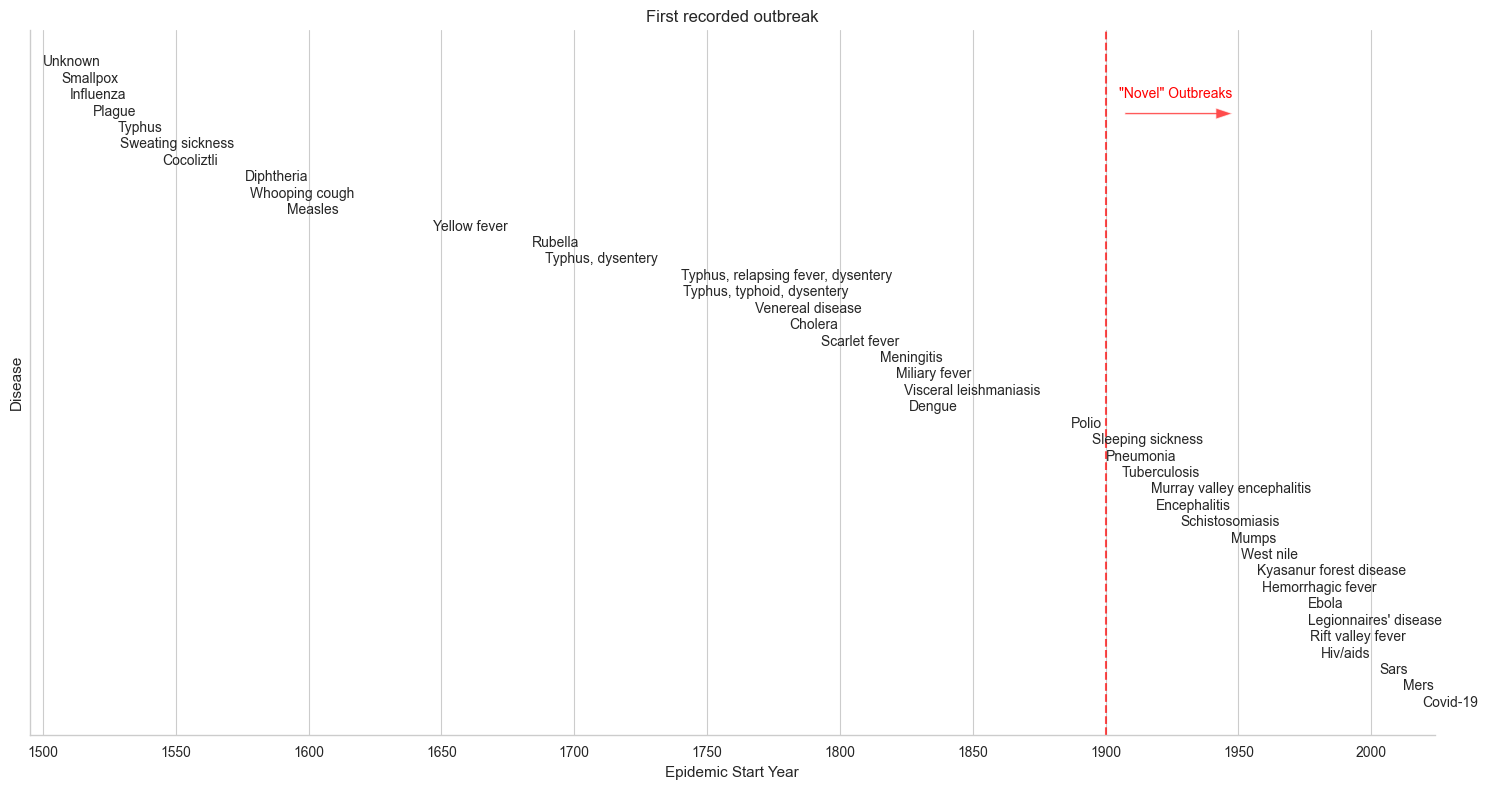

In [14]:
# Combine and sort diseases by start year
combined_df = pd.concat([viral_df, nonviral_df]).sort_values(by="year_start").reset_index(drop=True)

# Set up figure
fig, ax = plt.subplots(figsize=(15, 8))

# Dynamically scale y positions so they stay within a reasonable range
n = len(combined_df)  # Total number of diseases
y_positions = np.linspace(1, 0, n)  # Scale between 1 (top) and 0 (bottom)

# Plot each disease name at its corresponding year and cascading y-position
for i, (year, disease) in enumerate(zip(combined_df["year_start"], combined_df["disease"])):
    ax.text(year, y_positions[i], disease.capitalize(), fontsize=10, ha='left', va='center')

# Add a vertical line at 1900 to indicate dataset clipping
ax.axvline(x=1900, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(1905, 0.95, "\"Novel\" Outbreaks", 
        color='red', fontsize=10, ha='left', va='center', 
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
ax.annotate('', xy=(1950, 0.92), xytext=(1905, 0.92), # Add an arrow pointing forward
            arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8, alpha=0.7))

# Format x-axis
ax.set_xlabel("Epidemic Start Year", fontsize=11)
ax.set_xticks(np.arange(1500, 2050, 50))
ax.set_xlim(combined_df["year_start"].min() - 5, combined_df["year_start"].max() + 5)

# Fix the y-axis so it doesn't stretch too much
ax.set_ylim(-0.05, 1.05)  # Keep a tight fit around the text
ax.set_ylabel("Disease")

# Remove y-axis ticks since they aren't needed
ax.set_yticks([])
# Remove unnecessary spines for a cleaner look.
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Optionally add a title or adjust layout.
ax.set_title("First recorded outbreak", fontsize=12)
plt.tight_layout()

plt.savefig(figdir / '23_novel_disease_arrival.jpg', dpi=400, bbox_inches = 'tight')